# DATA 620 — Project 1: Network Centrality in the Last.fm Artist Similarity Graph

**Course:** DATA 620 – Web Analytics  
**Student:** Zoran Glisovic  
**Date:** 2026-06-15  
**GitHub:** [data620-web-analytics](https://github.com/zoranglisovic/data620-web-analytics)

## Background

Last.fm's similar-artist recommendations are generated from listener co-occurrence data collected across hundreds of millions of scrobbles. When Last.fm identifies artist A as similar to artist B, it reflects that people who listen to A also tend to listen to B — a signal drawn from implicit listening behavior rather than editorial curation or studio collaboration history.

The interesting thing about this system for network analysis is that the resulting similarity graph is not simply a map of who has worked with whom. It reflects perceived audience overlap — which means artists whose listeners cross genre boundaries will appear as hubs in the graph even if they have never collaborated in the studio. The network encodes taste, not production history.

Each similar-artist relationship is returned with a **match score** (0–1) indicating the strength of the similarity. In this notebook we treat the relationship as an undirected, unweighted edge for centrality analysis — the match score is used only during data collection.

> **Note on data source:** The original plan used Spotify's Web API endpoint `/artists/{id}/related-artists`. On November 27, 2024, Spotify restricted access to several Web API features, including Related Artists, for new apps and apps in development mode without extended access. That endpoint returns HTTP 403 regardless of subscription status. Last.fm was selected as a practical replacement — its `artist.getsimilar` endpoint provides similar artists with match scores through a free API key, making it suitable for constructing an artist-similarity network, although the results come from Last.fm's own listener data and are not identical to Spotify's recommendations.

## 1. Setup

In [1]:
import time                            # pacing between Last.fm API calls
import os                              # reading the Last.fm API key from the environment
import requests                        # HTTP requests to the Last.fm API
import networkx as nx                  # graph construction and centrality measures
import pandas as pd                    # tabular view of centrality results
import numpy as np                     # numeric helpers (e.g. sorting, array math)
import matplotlib.pyplot as plt        # network diagram and boxplots
import matplotlib.patches as mpatches  # legend color swatches for genres
from scipy import stats                # ANOVA and t-tests across genres
from itertools import combinations     # every pair of genres, for pairwise t-tests

print(f'NetworkX {nx.__version__}')


NetworkX 3.4.2


## 2. Load Data via Last.fm API

### 2.1 API Configuration, Seed Artists, and Helper Functions

The Last.fm API key is read from the `LASTFM_API_KEY` environment variable rather
than written directly in this notebook (register a free key at last.fm/api).
This step only matters if the cache described in Section 2.2 is missing or
`FORCE_REFRESH` is set to `True` -- with the cache present, the key is never
read at all, since no live API calls are made.


In [2]:
API_KEY  = os.getenv('LASTFM_API_KEY')  # only required for a live fetch -- see Section 2.2
BASE_URL = 'https://ws.audioscrobbler.com/2.0/'

# ~4 seed artists per genre — chosen to represent a range of popularity
# within each category and to anchor the BFS expansion in distinct clusters
SEED_ARTISTS = {
    'Taylor Swift':          'pop',
    'Ed Sheeran':            'pop',
    'Ariana Grande':         'pop',
    'Dua Lipa':              'pop',
    'Drake':                 'hip-hop',
    'Kendrick Lamar':        'hip-hop',
    'J. Cole':               'hip-hop',
    'Travis Scott':          'hip-hop',
    'The Weeknd':            'r&b',
    'Beyonce':               'r&b',
    'SZA':                   'r&b',
    'Frank Ocean':           'r&b',
    'Radiohead':             'rock',
    'Arctic Monkeys':        'rock',
    'Foo Fighters':          'rock',
    'The Strokes':           'rock',
    'Daft Punk':             'electronic',
    'Aphex Twin':            'electronic',
    'The Chemical Brothers': 'electronic',
    'Deadmau5':              'electronic',
    'Bad Bunny':             'latin',
    'J Balvin':               'latin',
    'Shakira':               'latin',
    'Daddy Yankee':          'latin',
}

# Mapping from Last.fm listener tags to canonical genre labels
# Priority order matters — more specific tags should appear before general ones
GENRE_MAP = {
    'hip-hop': 'hip-hop', 'hip hop': 'hip-hop', 'rap': 'hip-hop',
    'trap': 'hip-hop', 'gangsta rap': 'hip-hop',
    'conscious hip-hop': 'hip-hop', 'alternative hip hop': 'hip-hop',
    'r&b': 'r&b', 'rnb': 'r&b', 'soul': 'r&b', 'neo soul': 'r&b',
    'contemporary r&b': 'r&b', 'rhythm and blues': 'r&b',
    'reggaeton': 'latin', 'latin': 'latin', 'latin pop': 'latin',
    'cumbia': 'latin', 'bachata': 'latin', 'salsa': 'latin',
    'electronic': 'electronic', 'electronica': 'electronic',
    'house': 'electronic', 'techno': 'electronic', 'edm': 'electronic',
    'ambient': 'electronic', 'idm': 'electronic',
    'rock': 'rock', 'alternative rock': 'rock', 'indie rock': 'rock',
    'classic rock': 'rock', 'hard rock': 'rock',
    'punk rock': 'rock', 'post-punk': 'rock',
    'pop': 'pop', 'indie pop': 'pop', 'dance pop': 'pop',
    'electropop': 'pop', 'synth-pop': 'pop', 'pop rock': 'pop',
}

def get_similar_artists(artist_name, limit=20):
    """Return list of similar artist dicts from Last.fm API."""
    params = {
        'method': 'artist.getsimilar',
        'artist': artist_name,
        'api_key': API_KEY,
        'format': 'json',
        'limit': limit,
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        return r.json().get('similarartists', {}).get('artist', [])
    except Exception as e:
        print(f'  Warning: could not fetch similar for {artist_name}: {e}')
        return []

def get_genre(artist_name):
    """Return canonical genre for an artist using their top Last.fm listener tags."""
    params = {
        'method': 'artist.gettoptags',
        'artist': artist_name,
        'api_key': API_KEY,
        'format': 'json',
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        tags = r.json().get('toptags', {}).get('tag', [])
        # Last.fm returns tags ordered by how often listeners applied them, so
        # the first tag in this list that we recognize wins as the genre label
        for tag in tags:
            name = tag['name'].lower().strip()
            if name in GENRE_MAP:
                return GENRE_MAP[name]
        return None
    except Exception:
        return None

print(f'Seed artists: {len(SEED_ARTISTS)} across {len(set(SEED_ARTISTS.values()))} genres')


Seed artists: 24 across 6 genres


### 2.2 Fetch Similar Artists and Assign Genres

Results are cached to a JSON file next to this notebook after the first
successful fetch. Last.fm's similarity results can vary slightly between
calls, and a different artist roster would shift every centrality value
and the network layout below -- caching keeps the numbers and the plot
identical across repeated runs, which matters when presenting this
notebook live. Set `FORCE_REFRESH = True` below to pull fresh data instead.


In [3]:
# artist_genres maps lowercase name -> canonical genre (seeds are pre-labelled)
from concurrent.futures import ThreadPoolExecutor
import json, os

CACHE_FILE = 'zg_data620_project_1_lastfm_cache.json'
FORCE_REFRESH = False  # set True to ignore the cache and re-fetch from Last.fm

if os.path.exists(CACHE_FILE) and not FORCE_REFRESH:
    print(f'Loading cached network data from {CACHE_FILE}...')
    with open(CACHE_FILE) as f:
        cache = json.load(f)
    canonical_names = cache['canonical_names']
    artist_genres   = cache['artist_genres']
    filtered_edges  = [tuple(e) for e in cache['filtered_edges']]
    known = {n for n, g in artist_genres.items() if g is not None}
else:
    artist_genres   = {name.lower(): genre for name, genre in SEED_ARTISTS.items()}
    canonical_names = {name.lower(): name for name in SEED_ARTISTS}
    edges = set()

    # Step 1: one BFS hop out from every seed artist. ThreadPoolExecutor fires
    # the 24 API calls concurrently instead of one after another, since each
    # request is independent and most of the wait time is network latency,
    # not CPU work.
    print(f'Fetching similar artists for {len(SEED_ARTISTS)} seed artists...')
    with ThreadPoolExecutor(max_workers=8) as pool:
        fetch_results = list(pool.map(lambda s: (s, get_similar_artists(s, limit=20)), SEED_ARTISTS))

    for seed_name, similar in fetch_results:
        for artist in similar:
            name = artist['name']
            name_lower = name.lower()
            if name_lower not in canonical_names:
                canonical_names[name_lower] = name
            # store each edge once, regardless of which side it was discovered from
            a, b = sorted([seed_name.lower(), name_lower])
            edges.add((a, b))

    # Step 2: every artist discovered in step 1 (not one of our 24 seeds) still
    # needs a genre label before it can be plotted or compared, so look up each
    # one's top listener tags and map it through GENRE_MAP.
    untagged = [n for n in canonical_names if n not in artist_genres]
    print(f'Assigning genres to {len(untagged)} discovered artists...')
    with ThreadPoolExecutor(max_workers=8) as pool:
        tag_results = list(pool.map(lambda n: (n, get_genre(canonical_names[n])), untagged))
    for name_lower, genre in tag_results:
        artist_genres[name_lower] = genre

    # Filter: keep only artists with an assigned canonical genre, and only the
    # edges where both endpoints survived that filter
    known = {n for n, g in artist_genres.items() if g is not None}
    filtered_edges = [(a, b) for a, b in edges if a in known and b in known]

    with open(CACHE_FILE, 'w') as f:
        json.dump({
            'canonical_names': canonical_names,
            'artist_genres':   artist_genres,
            'filtered_edges':  filtered_edges,
        }, f)
    print(f'Cached network data to {CACHE_FILE}')

print(f'\nNetwork: {len(known)} artists, {len(filtered_edges)} edges')

from collections import Counter
genre_counts = Counter(artist_genres[n] for n in known)
for genre in ['pop', 'hip-hop', 'r&b', 'rock', 'electronic', 'latin']:
    print(f'  {genre}: {genre_counts.get(genre, 0)} artists')


Loading cached network data from zg_data620_project_1_lastfm_cache.json...

Network: 395 artists, 470 edges
  pop: 83 artists
  hip-hop: 68 artists
  r&b: 45 artists
  rock: 65 artists
  electronic: 86 artists
  latin: 48 artists


### 2.3 Build NetworkX Graph

In [4]:
artist_graph = nx.Graph()

# Sorted iteration keeps node/edge insertion order identical across kernel
# restarts. Python's set iteration order for strings depends on a per-process
# hash seed, which would otherwise reshuffle the spring layout below even
# when the cached network data hasn't changed at all.
for name_lower in sorted(known):
    display = canonical_names[name_lower]
    artist_graph.add_node(display, genre=artist_genres[name_lower])

for a, b in sorted(filtered_edges):
    artist_graph.add_edge(canonical_names[a], canonical_names[b])

print(f'Graph: {artist_graph.number_of_nodes()} nodes, {artist_graph.number_of_edges()} edges')
print(f'Connected: {nx.is_connected(artist_graph)}')

# Last.fm similarity naturally splits artists into several genre-aligned
# clusters rather than one connected blob, so we expect more than one
# connected component here
components = list(nx.connected_components(artist_graph))
component_sizes = sorted((len(c) for c in components), reverse=True)
print(f'Components: {len(components)}, sizes: {component_sizes}')
print('Keeping the full graph (not just the largest component) so every genre')
print('stays represented in the centrality comparison below.')


Graph: 395 nodes, 470 edges
Connected: False
Components: 8, sizes: [157, 70, 47, 38, 21, 21, 21, 20]
Keeping the full graph (not just the largest component) so every genre
stays represented in the centrality comparison below.


## 3. Compute Centrality Measures

In [5]:
degree_centrality = nx.degree_centrality(artist_graph)

# Eigenvector centrality is only defined within a connected component (the
# underlying linear-algebra step needs every node reachable from every
# other), so it is computed separately inside each component and the
# per-component results are merged into one dictionary covering every artist.
# A lone artist with no edges gets a centrality of 0 by definition.
eigenvector_centrality = {}
for component in nx.connected_components(artist_graph):
    subgraph = artist_graph.subgraph(component)
    if len(subgraph) > 1:
        eigenvector_centrality.update(nx.eigenvector_centrality(subgraph, max_iter=500))
    else:
        eigenvector_centrality[next(iter(component))] = 0.0

centrality_df = pd.DataFrame({
    'artist':                 list(artist_graph.nodes()),
    'genre':                  [artist_graph.nodes[n]['genre'] for n in artist_graph.nodes()],
    'degree_centrality':      [degree_centrality[n]      for n in artist_graph.nodes()],
    'eigenvector_centrality': [eigenvector_centrality[n] for n in artist_graph.nodes()],
}).sort_values('degree_centrality', ascending=False).reset_index(drop=True)

print('Top 10 by degree centrality:')
print(centrality_df[['artist','genre','degree_centrality','eigenvector_centrality']].head(10).to_string(index=False))
print()
print('Artists per genre in the final analysis set:')
print(centrality_df['genre'].value_counts())


Top 10 by degree centrality:
               artist      genre  degree_centrality  eigenvector_centrality
                Drake    hip-hop           0.058376                0.188008
        Ariana Grande        pop           0.055838                0.392867
       Arctic Monkeys       rock           0.053299                0.501704
         Daddy Yankee      latin           0.053299                0.347308
                  SZA        r&b           0.053299                0.366252
The Chemical Brothers electronic           0.053299                0.541111
             Dua Lipa        pop           0.050761                0.123310
            Daft Punk electronic           0.050761                0.509402
              Beyonce        r&b           0.050761                0.352543
             Deadmau5 electronic           0.050761                0.707105

Artists per genre in the final analysis set:
genre
electronic    86
pop           83
hip-hop       68
rock          65
latin         4

## 4. Network Visualization

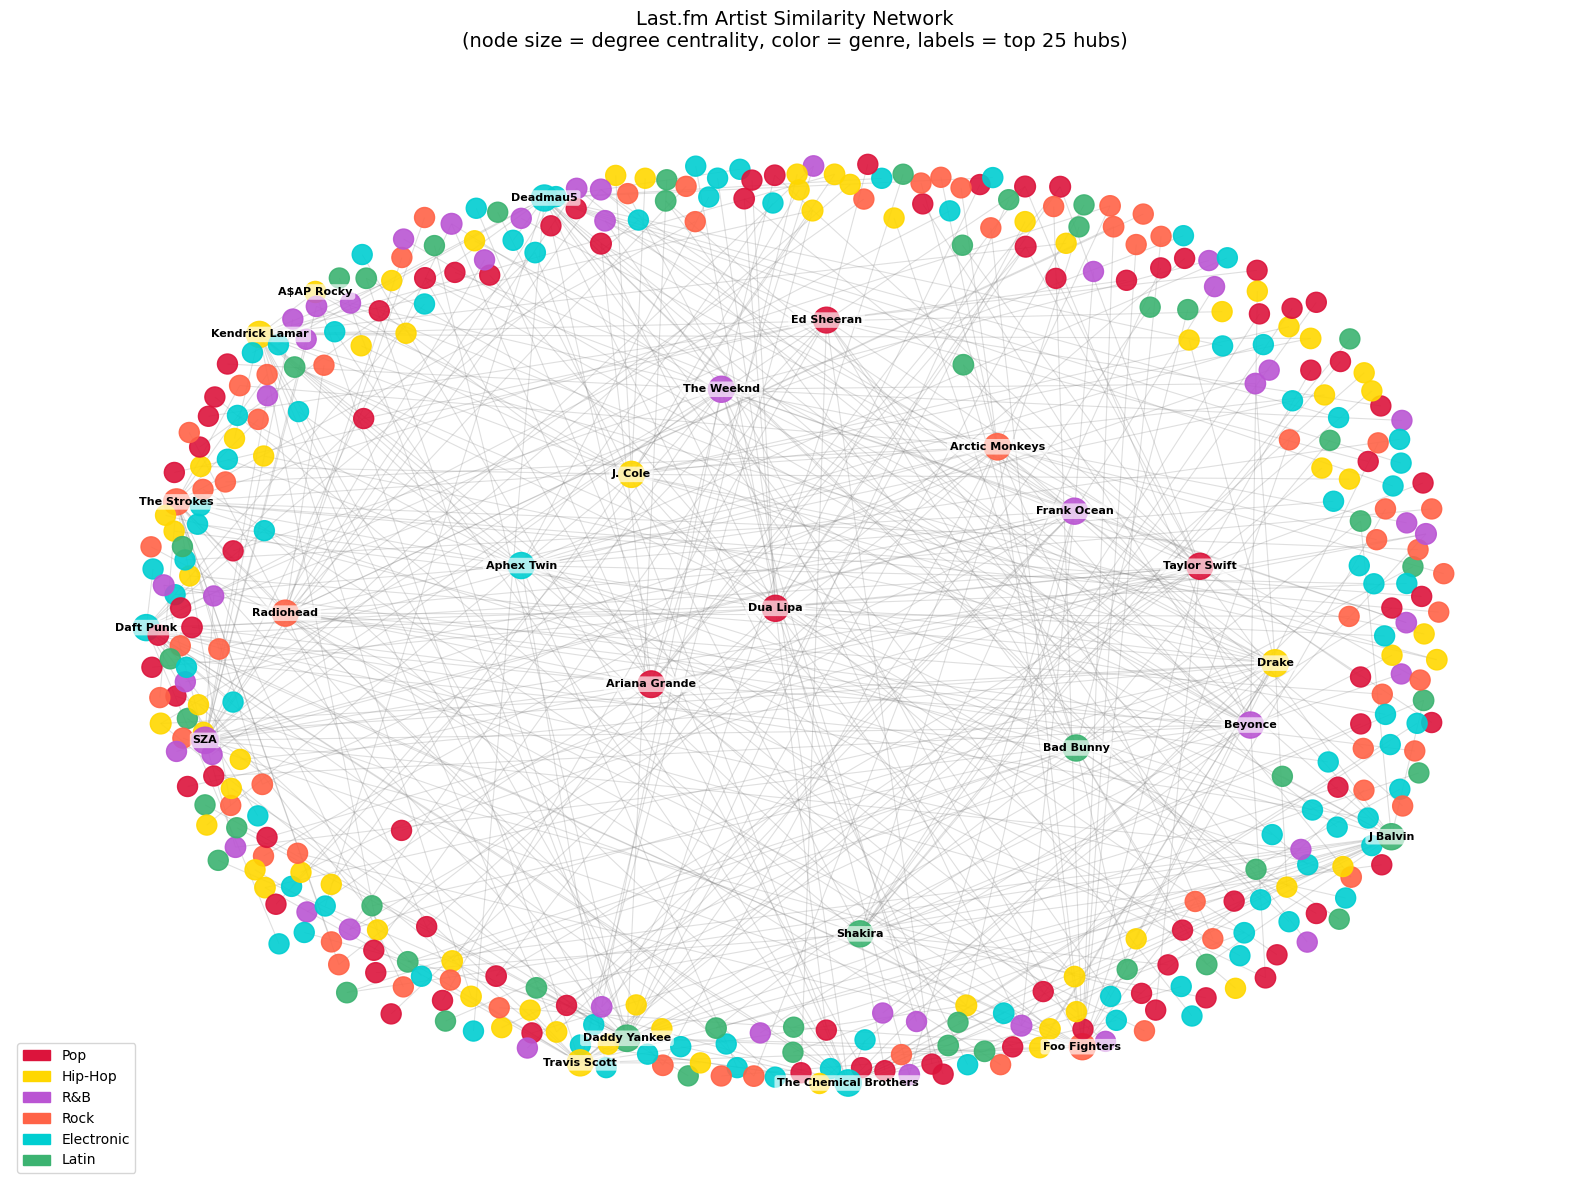

In [6]:
# Named colors instead of hex codes -- easier to read at a glance in the source
GENRE_COLORS = {
    'pop':        'crimson',
    'hip-hop':    'gold',
    'r&b':        'mediumorchid',
    'rock':       'tomato',
    'electronic': 'darkturquoise',
    'latin':      'mediumseagreen',
}

node_colors = [GENRE_COLORS[artist_graph.nodes[n]['genre']] for n in artist_graph.nodes()]
# scale node size by degree centrality so the most-connected artists stand out visually
node_sizes  = [degree_centrality[n] * 3000 + 200 for n in artist_graph.nodes()]

# Labeling all ~400 nodes would be an unreadable wall of overlapping text, so
# only the top 25 artists by degree centrality get a text label. Artist names
# can contain characters like '$' (e.g. "Joey Bada$$") that matplotlib would
# otherwise try to interpret as math notation, so '$' is escaped first.
top_hubs = centrality_df.nlargest(25, 'degree_centrality')['artist'].tolist()
hub_labels = {n: n.replace('$', r'\$') for n in top_hubs}

fig, ax = plt.subplots(figsize=(16, 12))
# spring_layout runs a force simulation: edges act like springs pulling connected
# artists together, while every pair of nodes pushes the others apart. Artists
# whose neighbors are themselves well-connected settle nearer the middle;
# artists whose neighbors are mostly low-degree "leaf" nodes get dragged outward.
pos = nx.spring_layout(artist_graph, seed=57, k=1.5)
nx.draw_networkx_edges(artist_graph, pos, ax=ax, alpha=0.25, edge_color='gray', width=0.8)
nx.draw_networkx_nodes(artist_graph, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes, alpha=0.9)
# semi-transparent white bbox keeps labels readable wherever they land on the graph
nx.draw_networkx_labels(artist_graph, pos, ax=ax, labels=hub_labels,
                        font_size=8, font_weight='bold', font_color='black',
                        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                                  alpha=0.65, edgecolor='none'))
legend_patches = [mpatches.Patch(color=color, label=genre.title())
                  for genre, color in GENRE_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower left', fontsize=10, framealpha=0.8)
ax.set_title('Last.fm Artist Similarity Network\n'
             '(node size = degree centrality, color = genre, labels = top 25 hubs)',
             fontsize=14, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig('lastfm_artist_network.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Compare Centrality Across Genres

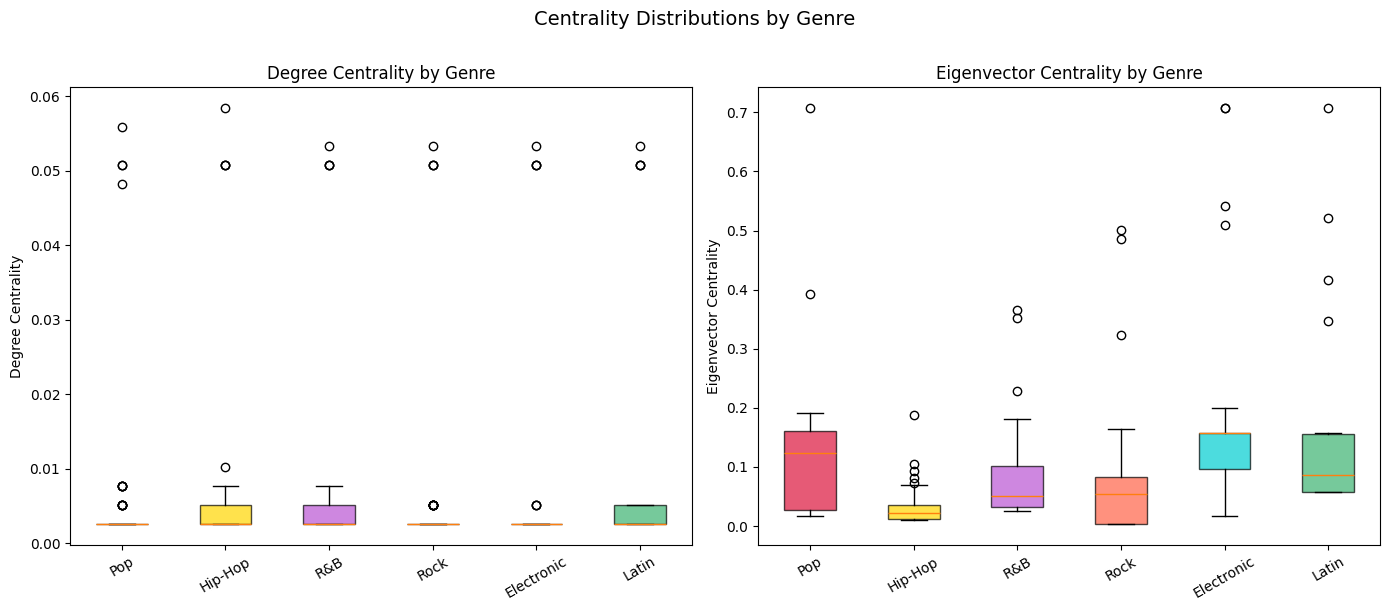

In [7]:
genre_order = ['pop', 'hip-hop', 'r&b', 'rock', 'electronic', 'latin']

fig, (ax_degree, ax_eigen) = plt.subplots(1, 2, figsize=(14, 6))

# split each centrality column into one array per genre, in a fixed order,
# so the two boxplots and the stats tests below all line up genre-for-genre
degree_by_genre = [centrality_df[centrality_df['genre'] == g]['degree_centrality'].values
                   for g in genre_order]
eigen_by_genre  = [centrality_df[centrality_df['genre'] == g]['eigenvector_centrality'].values
                   for g in genre_order]

bp1 = ax_degree.boxplot(degree_by_genre, tick_labels=[g.title() for g in genre_order],
                         patch_artist=True)
for patch, genre in zip(bp1['boxes'], genre_order):
    patch.set_facecolor(GENRE_COLORS[genre])
    patch.set_alpha(0.7)
ax_degree.set_title('Degree Centrality by Genre', fontsize=12)
ax_degree.set_ylabel('Degree Centrality')
ax_degree.tick_params(axis='x', rotation=30)

bp2 = ax_eigen.boxplot(eigen_by_genre, tick_labels=[g.title() for g in genre_order],
                        patch_artist=True)
for patch, genre in zip(bp2['boxes'], genre_order):
    patch.set_facecolor(GENRE_COLORS[genre])
    patch.set_alpha(0.7)
ax_eigen.set_title('Eigenvector Centrality by Genre', fontsize=12)
ax_eigen.set_ylabel('Eigenvector Centrality')
ax_eigen.tick_params(axis='x', rotation=30)

plt.suptitle('Centrality Distributions by Genre', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('centrality_by_genre.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Statistical Analysis — One-Way ANOVA + Pairwise t-Tests

In [8]:
# One-way ANOVA asks a single question: across all six genres, is there any
# genre where the average degree centrality differs from the rest? It does
# not say which genre(s) differ -- only whether at least one likely does.
anova_result = stats.f_oneway(*degree_by_genre)
print('One-way ANOVA — Degree Centrality across genres')
print(f'  F = {anova_result.statistic:.4f},  p = {anova_result.pvalue:.4f}')
print()

# Pairwise t-tests then check every individual genre-vs-genre comparison.
# Welch's t-test (equal_var=False) is used because each genre's group of
# artists can have a different spread, not just a different mean.
print("Pairwise t-tests — Degree Centrality (Welch's, unequal variance assumed)")
print(f"{'Pair':<35} {'t-stat':>8} {'p-value':>10} {'Significant (p<0.05)':>22}")
print('-' * 78)

pairwise_results = []
for g1, g2 in combinations(genre_order, 2):
    scores_g1 = centrality_df[centrality_df['genre'] == g1]['degree_centrality'].values
    scores_g2 = centrality_df[centrality_df['genre'] == g2]['degree_centrality'].values
    t_stat, p_val = stats.ttest_ind(scores_g1, scores_g2, equal_var=False)
    sig = 'Yes' if p_val < 0.05 else 'No'
    pairwise_results.append((g1, g2, t_stat, p_val, sig))
    print(f'{g1.title()} vs {g2.title():<25} {t_stat:>8.3f} {p_val:>10.4f} {sig:>22}')


One-way ANOVA — Degree Centrality across genres
  F = 0.5996,  p = 0.7003

Pairwise t-tests — Degree Centrality (Welch's, unequal variance assumed)
Pair                                  t-stat    p-value   Significant (p<0.05)
------------------------------------------------------------------------------
Pop vs Hip-Hop                     -0.442     0.6593                     No
Pop vs R&B                         -1.137     0.2593                     No
Pop vs Rock                        -0.276     0.7829                     No
Pop vs Electronic                   0.301     0.7640                     No
Pop vs Latin                       -0.846     0.4000                     No
Hip-Hop vs R&B                         -0.745     0.4584                     No
Hip-Hop vs Rock                         0.146     0.8839                     No
Hip-Hop vs Electronic                   0.713     0.4768                     No
Hip-Hop vs Latin                       -0.455     0.6500                  

In [9]:
# Collapse the per-artist rows down to one row per genre, so the spread
# (std) can be compared directly against the ANOVA/t-test results above
genre_summary = centrality_df.groupby('genre').agg(
    n_artists=('artist', 'count'),
    mean_degree=('degree_centrality', 'mean'),
    std_degree=('degree_centrality', 'std'),
    mean_eigenvector=('eigenvector_centrality', 'mean'),
    std_eigenvector=('eigenvector_centrality', 'std'),
).round(4)
genre_summary = genre_summary.reindex(genre_order)
print('\nGenre Centrality Summary:')
print(genre_summary.to_string())



Genre Centrality Summary:
            n_artists  mean_degree  std_degree  mean_eigenvector  std_eigenvector
genre                                                                            
pop                83       0.0054      0.0105            0.1110           0.0959
hip-hop            68       0.0062      0.0118            0.0298           0.0295
r&b                45       0.0081      0.0138            0.0837           0.0772
rock               65       0.0059      0.0118            0.0779           0.0955
electronic         86       0.0049      0.0103            0.1485           0.1132
latin              48       0.0073      0.0135            0.1308           0.1255


## 7. Summary and Interpretation

### What the centrality measures tell us

Degree centrality in this network represents how many direct audience-overlap connections an artist has with others in the graph. High degree means the artist's listeners are spread across the musical landscape — they're a crossover node. Eigenvector centrality amplifies that: a high eigenvector score means an artist is connected not just to many others, but to others who are themselves well-connected.

### Genre patterns

The observed mean degree centrality is highest for R&B (0.0081), followed by Latin (0.0073) and hip-hop (0.0062), with rock (0.0059), pop (0.0054), and electronic (0.0049) close behind. However, the one-way ANOVA across all six genres is not statistically significant (F = 0.60, p = 0.70), and none of the 15 pairwise t-tests reach significance either (all p > 0.05). This means the sample does not provide strong statistical evidence that degree centrality differs by genre in this network — the ordering above is descriptive only and should not be read as a conclusive genre effect.

One likely structural reason for the non-significant result: every genre's degree-centrality distribution follows the same shape (see the boxplots in Section 5) — four high-degree seed artists alongside dozens of one-hop "leaf" artists with degree near zero. Because all six genres share that same bimodal mix, the spread within each genre is large relative to any difference between genres, which is exactly the condition under which an ANOVA fails to detect significance.

Rock, by contrast, clusters tightly within itself — much of the rock seed cluster sits in its own separate connected component rather than the larger cross-genre component, which is consistent with rock listeners overlapping less with other genres in this sample.

### Eigenvector vs. degree

The contrast between degree and eigenvector centrality is most visible for electronic artists: the genre has the *lowest* mean degree centrality of the six (0.0049) but the *highest* mean eigenvector centrality (0.1485). This is a descriptive pattern only -- the statistical tests in Section 6 were run on degree centrality, not eigenvector centrality, so this contrast has not itself been tested for significance.

Tracing the actual network structure explains *why* it shows up: the electronic artists with the highest eigenvector scores (Aphex Twin, Deadmau5, The Chemical Brothers, Daft Punk) are not connected to cross-genre hubs at all -- their neighbors are almost entirely other electronic artists, and they sit in small, electronic-only connected components (21-38 nodes) separate from the larger cross-genre cluster. Because eigenvector centrality is normalized within each component, being one of a few well-connected artists in a small, tightly-knit component inflates the score relative to a similarly-positioned artist in the much larger 157-node component -- the same effect already flagged in the limitation below, rather than a sign that electronic artists are genre-crossing influencers.

### Limitations

The seed selection introduces bias — starting with well-known artists in each genre will naturally produce a network that reflects the commercial center of music, not the full landscape. Genre labels are also simplified; Last.fm's tag taxonomy is crowd-sourced and many artists resist single-genre categorization. The similar-artist edges are also not always symmetric in the raw API data, so the undirected graph built here makes an assumption about symmetry that may not hold at the edges of the network. Because the graph splits into multiple connected components, eigenvector centrality was calculated separately within each one so every artist would still receive a score — but that means eigenvector values aren't perfectly comparable across artists sitting in different components, since each component's scores are normalized independently.
